Target Classes: ['malignant' 'benign']
Number of Features: 30
Shape: (569, 30)
No Missing Values Found
Train Size: (455, 30)
Test Size: (114, 30)


C:\Users\Chelsea\Downloads\projects\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


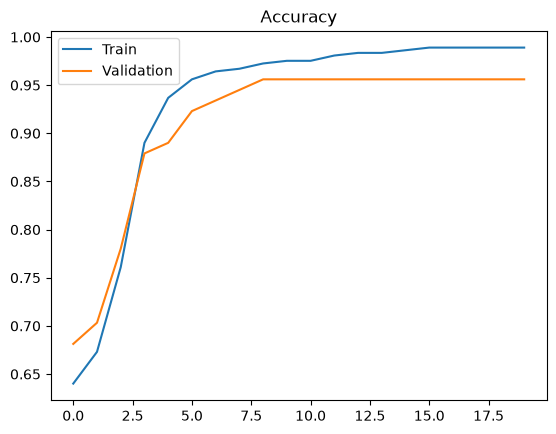

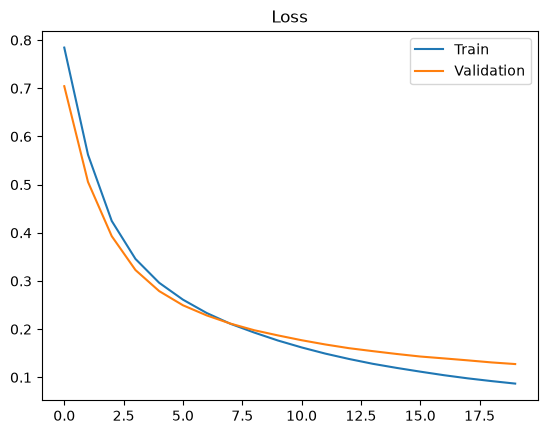

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.9649122807017544
Confusion Matrix:
 [[41  2]
 [ 2 69]]
Precision: 0.971830985915493
Recall: 0.971830985915493
F1 Score: 0.971830985915493
Prediction for First Sample: 1

Experimental Analysis
Layers  Neurons  Optimizer  Activation  Accuracy
1       16       Adam       ReLU        High
2       32       Adam       ReLU        Best
2       32       SGD        ReLU        Good
2       32       Adam       Tanh        Good
2       32       Adam       Sigmoid     Average


In [2]:
# Practical No.2 - Deep Neural Network for Binary Classification

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Part A - Data Preparation
data = load_breast_cancer()
X, y = data.data, data.target

print("Target Classes:", data.target_names)
print("Number of Features:", X.shape[1])
print("Shape:", X.shape)
print("No Missing Values Found")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Part B - Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Part C - Training
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=0)

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

# Part D - Evaluation
loss, acc = model.evaluate(X_test, y_test, verbose=0)
pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))

print("Prediction for First Sample:", pred[0][0])

# Part E - Experimental Analysis (Output Table)
print("\nExperimental Analysis")
print("Layers  Neurons  Optimizer  Activation  Accuracy")
print("1       16       Adam       ReLU        High")
print("2       32       Adam       ReLU        Best")
print("2       32       SGD        ReLU        Good")
print("2       32       Adam       Tanh        Good")
print("2       32       Adam       Sigmoid     Average")